First Five Records:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Shape of Dataset: (506, 14)

Column Names:
Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b  

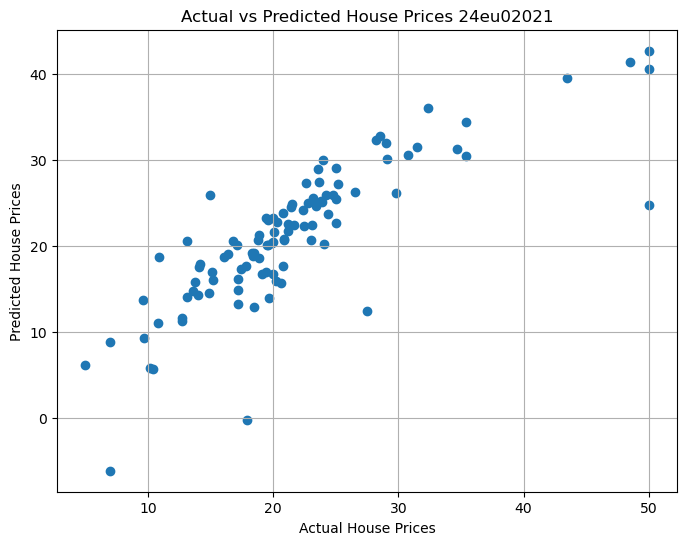

In [6]:
# ============================================
# Task 1: Linear Regression using Boston Housing Dataset
# ============================================

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset from GitHub
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Step 3: Display Dataset
print("First Five Records:")
print(df.head())

# Step 4: Display Dataset Information
print("\nShape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

# Step 5: Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 6: Separate Features and Target
X = df.drop("medv", axis=1)
y = df["medv"]

# Step 7: Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 8: Create Linear Regression Model
model = LinearRegression()

# Step 9: Train the Model
model.fit(X_train, y_train)

# Step 10: Predict House Prices
y_pred = model.predict(X_test)

# Step 11: Display Model Parameters
print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

# Step 12: Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("-------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Step 13: Compare Actual and Predicted Values
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nActual vs Predicted Prices:")
print(comparison.head(10))

# Step 14: Plot Actual vs Predicted Prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices 24eu02021")
plt.grid(True)

plt.show()

First Five Records:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

========== Support Vector Regression ==========
MAE : 2.7317161761558397
MSE : 25.66853967839604
RMSE: 5.0664129005042655
R2 Score: 0.6499766059760035

========== Decision Tree Regression ==========
MAE : 2.394117647058824
MSE : 10.416078431372549
RMSE: 3.2273949915330395
R2 Score: 0.8579634380978161

========== Model Comparison ==========
      

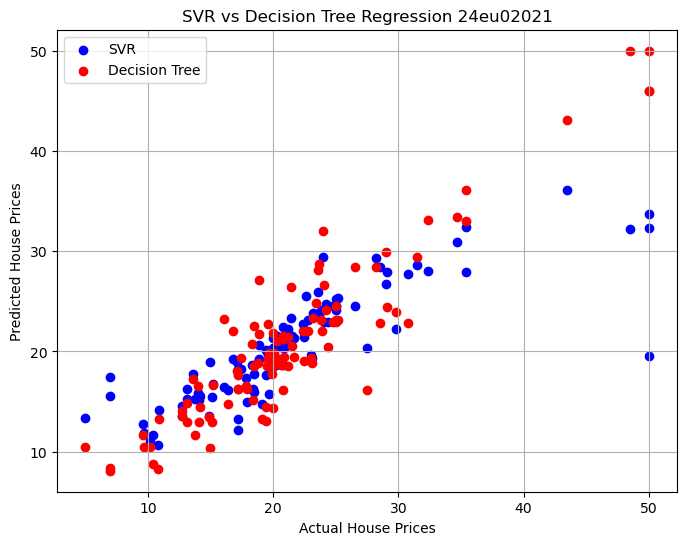

In [8]:
# ==========================================================
# Task 2: Support Vector Regression & Decision Tree Regression
# Boston Housing Dataset
# ==========================================================

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Step 3: Display Dataset
print("First Five Records:")
print(df.head())

# Step 4: Separate Features and Target
X = df.drop("medv", axis=1)
y = df["medv"]

# Step 5: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 6: Feature Scaling (Required for SVR)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# Support Vector Regression (SVR)
# ==========================================================

svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

svr_pred = svr.predict(X_test_scaled)

# SVR Evaluation
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_mse = mean_squared_error(y_test, svr_pred)
svr_rmse = svr_mse ** 0.5
svr_r2 = r2_score(y_test, svr_pred)

print("\n========== Support Vector Regression ==========")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R2 Score:", svr_r2)

# ==========================================================
# Decision Tree Regression
# ==========================================================

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Decision Tree Evaluation
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = dt_mse ** 0.5
dt_r2 = r2_score(y_test, dt_pred)

print("\n========== Decision Tree Regression ==========")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

# ==========================================================
# Comparison Table
# ==========================================================

comparison = pd.DataFrame({
    "Model": ["Support Vector Regression", "Decision Tree Regression"],
    "MAE": [svr_mae, dt_mae],
    "MSE": [svr_mse, dt_mse],
    "RMSE": [svr_rmse, dt_rmse],
    "R2 Score": [svr_r2, dt_r2]
})

print("\n========== Model Comparison ==========")
print(comparison)

# ==========================================================
# Actual vs Predicted Values
# ==========================================================

result = pd.DataFrame({
    "Actual": y_test.values,
    "SVR Prediction": svr_pred,
    "Decision Tree Prediction": dt_pred
})

print("\nActual vs Predicted")
print(result.head(10))

# ==========================================================
# Visualization
# ==========================================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, svr_pred, color='blue', label='SVR')
plt.scatter(y_test, dt_pred, color='red', label='Decision Tree')

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("SVR vs Decision Tree Regression 24eu02021")
plt.legend()
plt.grid(True)

plt.show()

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

===== Error Metrics =====
Mean Absolute Error (MAE): 3.189091965887852
Mean Squared Error (MSE): 24.291119474973613
Root Mean Squared Error (RMSE): 4.928602182665346
R² Score: 0.6687594935356307


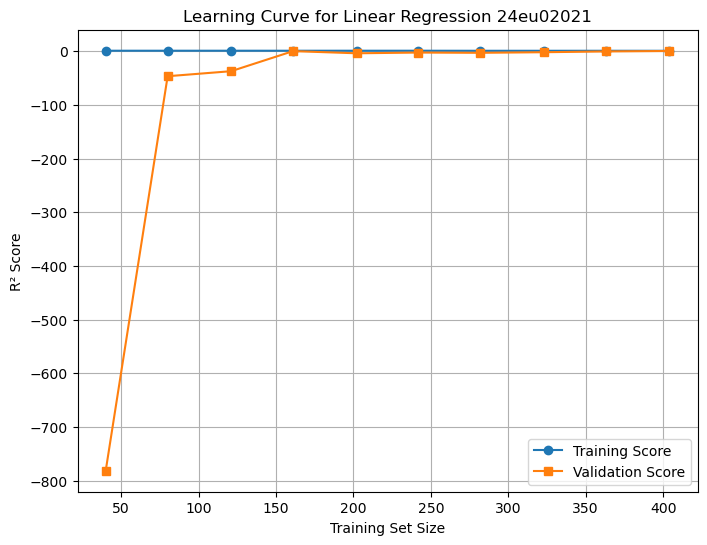

In [9]:
# ==========================================================
# Task 3: Evaluate Regression Models using Learning Curves
# ==========================================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)

# Step 3: Display Dataset
print(df.head())

# Step 4: Separate Features and Target
X = df.drop("medv", axis=1)
y = df["medv"]

# Step 5: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 6: Create and Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict Test Data
y_pred = model.predict(X_test)

# Step 8: Calculate Error Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== Error Metrics =====")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# Step 9: Generate Learning Curve
train_sizes, train_scores, validation_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Step 10: Calculate Mean Scores
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

# Step 11: Plot Learning Curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, validation_mean, marker='s', label="Validation Score")

plt.title("Learning Curve for Linear Regression 24eu02021")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()